# **Exploratory Data Analysis**

This notebook explores the AISI 4140 heat-treatment dataset before any modeling
takes place. The goal is to understand the shape and quality of the data, check
for missing values or duplicates, and look at how the process inputs
(austenitizing temperature, section thickness, quench medium, tempering
temperature, tempering time) relate to the mechanical properties we ultimately
want to predict (hardness, UTS, yield strength, elongation, reduction of area).

## 1. Importing Libraries and Loading the Dataset

Load the core data-handling and plotting libraries, mount Google Drive, and
read the dataset into a DataFrame.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading Dataset

df = pd.read_csv(
    "/content/drive/MyDrive/Heat_Treatment_Dashboard/data/aisi_4140_heat_treatment_dataset.csv"
)

df.head()


,austenitizing_temp_C,section_thickness_mm,quench_medium,tempering_temp_C,tempering_time_hr,hardness_HRC,UTS_MPa,YS_MPa,elongation_pct,reduction_of_area_pct,source
0,845.0,25.0,oil,815.0,1.0,13.0,655.0,415.0,25.7,56.9,literature_anchor_annealed
1,845.0,25.0,oil,316.0,1.0,47.0,1551.0,1372.6,12.0,42.0,literature_anchor
2,845.0,25.0,oil,538.0,1.0,26.0,896.0,672.0,18.0,55.0,literature_anchor
3,851.7,50.0,oil,384.7,4.0,38.8,1212.1,1004.6,17.1,44.3,physics_model
4,834.4,100.0,air,401.7,4.0,37.4,1177.4,952.6,19.3,44.9,physics_model


## 2. Basic Data Inspection

A first look at the dataset's size, column names, and data types, to confirm
it loaded as expected before going any further.

In [3]:
print("Dataset Shape:",df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1100, 11)

Column Names:
['austenitizing_temp_C', 'section_thickness_mm', 'quench_medium', 'tempering_temp_C', 'tempering_time_hr', 'hardness_HRC', 'UTS_MPa', 'YS_MPa', 'elongation_pct', 'reduction_of_area_pct', 'source']

Data Types:
austenitizing_temp_C     float64
section_thickness_mm     float64
quench_medium             object
tempering_temp_C         float64
tempering_time_hr        float64
hardness_HRC             float64
UTS_MPa                  float64
YS_MPa                   float64
elongation_pct           float64
reduction_of_area_pct    float64
source                    object
dtype: object


## 3. Data-Quality Verification

Check for missing values and duplicate rows. Both need to be understood (and
handled, if present) before any statistics or models are built on top of this
data.

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
austenitizing_temp_C     0
section_thickness_mm     0
quench_medium            0
tempering_temp_C         0
tempering_time_hr        0
hardness_HRC             0
UTS_MPa                  0
YS_MPa                   0
elongation_pct           0
reduction_of_area_pct    0
source                   0
dtype: int64

Duplicate rows:
0


## 4. Separate Inputs and Targets

Define the process-parameter input features and the mechanical-property
target columns explicitly, so the rest of the analysis (and later modeling)
can refer to them consistently.

In [5]:
input_features =[
    "austenitizing_temp_C",
    "section_thickness_mm",
    "quench_medium",
    "tempering_temp_C",
    "tempering_time_hr",
]

target_features = [
    "hardness_HRC",
    "UTS_MPa",
    "YS_MPa",
    "elongation_pct",
    "reduction_of_area_pct",
]

## 5. Descriptive Statistics

Summary statistics (mean, std, min/max, quartiles) for every numerical column,
as a quick sanity check on ranges and scale before visualizing distributions.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
austenitizing_temp_C,1100.0,850.096909,13.032329,828.0,838.800,849.80,861.400,871.9
section_thickness_mm,1100.0,64.889091,43.409727,13.0,25.000,50.00,100.000,150.0
tempering_temp_C,1100.0,418.995182,134.022222,202.5,295.300,414.95,533.025,815.0
tempering_time_hr,1100.0,1.815000,1.320760,0.5,0.500,1.00,2.000,4.0
hardness_HRC,1100.0,36.394364,11.210849,13.0,25.800,37.40,47.125,54.5
UTS_MPa,1100.0,1218.665182,340.275244,655.0,905.300,1198.60,1540.950,1923.3
YS_MPa,1100.0,976.873455,356.674075,415.0,640.425,945.60,1313.100,1687.6
elongation_pct,1100.0,18.426909,4.970071,8.7,13.900,18.65,22.900,28.4
reduction_of_area_pct,1100.0,43.034727,9.313425,24.9,34.600,43.80,51.200,64.3


## 6. Analyze the Categorical Variables

Look at the category counts for `quench_medium` and `source`, to see how
balanced each category is and whether any class is rare enough to cause
problems later (e.g. during train/test splitting).

In [7]:
print(df["quench_medium"].value_counts())
print()
print(df["source"].value_counts())

quench_medium
oil      770
water    210
air      120
Name: count, dtype: int64

source
physics_model                 1097
literature_anchor                2
literature_anchor_annealed       1
Name: count, dtype: int64


## 7. Distribution of Numerical Values

Histograms for every numerical column, to check for skew, multi-modality, or
any values that look out of place.

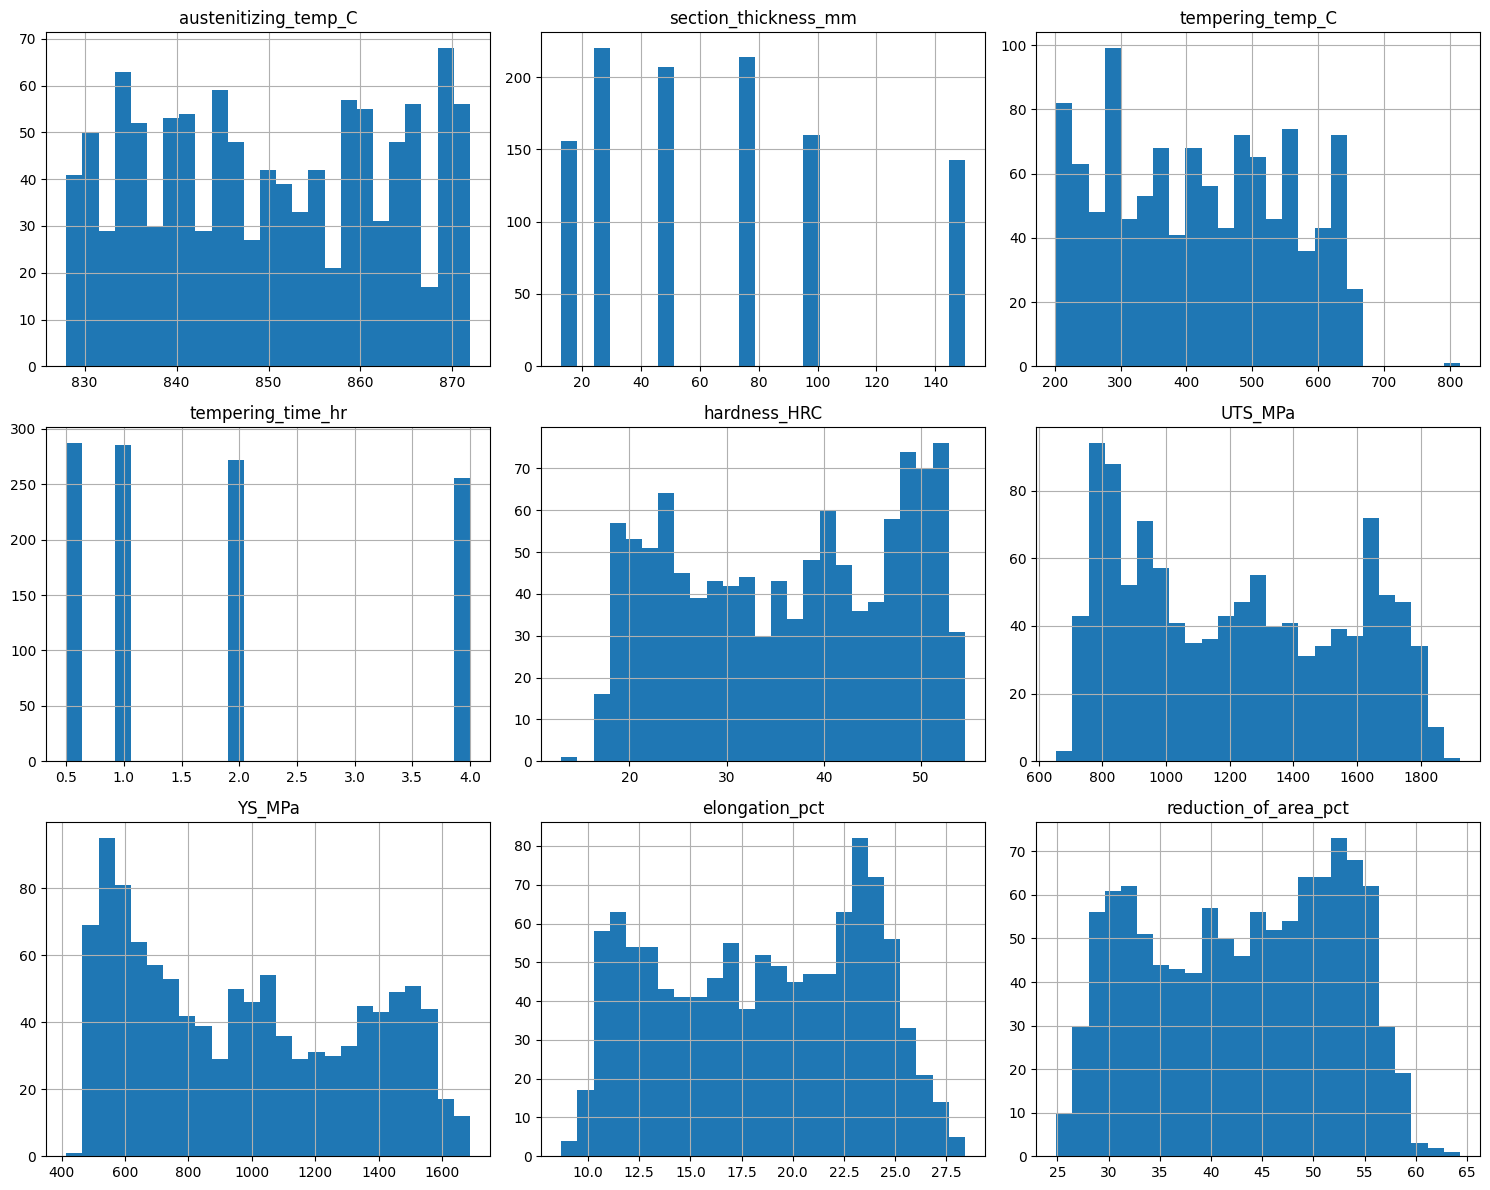

In [8]:
numerical_columns = df.select_dtypes(include=[np.number]).columns

df[numerical_columns].hist(
    figsize=(15, 12), bins=25
)

plt.tight_layout()
plt.show()

## 8. Boxplots for Outlier Inspection

Boxplots of the same numerical columns, side by side, to spot outliers and
compare spread across variables that may be on different scales.

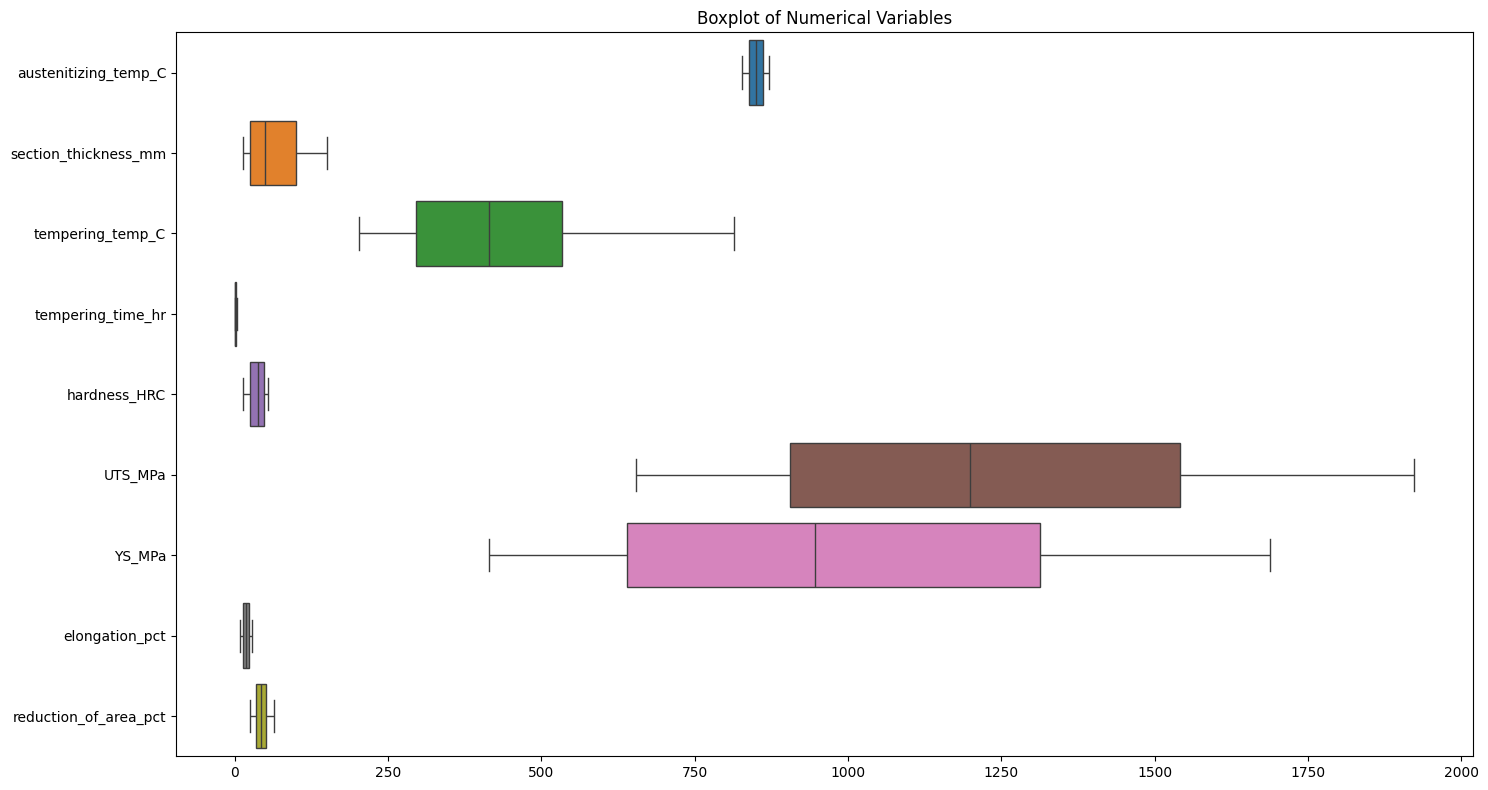

In [9]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df[numerical_columns],
    orient="h"
)

plt.title("Boxplot of Numerical Variables")
plt.tight_layout()
plt.show()

## 9. Correlation Analysis

A correlation heatmap across all numerical columns, to see which process
parameters move together with which mechanical properties (and which
properties move together with each other) before diving into individual
scatter plots.

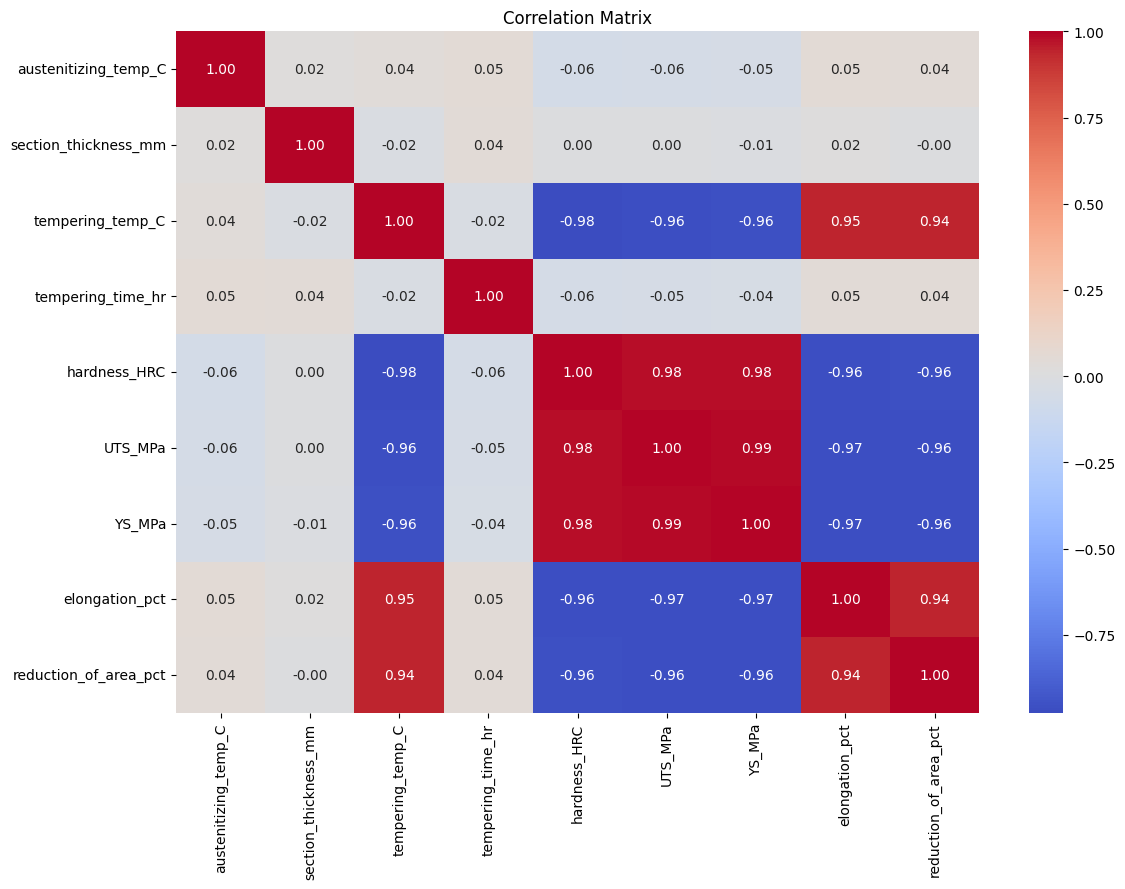

In [10]:
correlation = df[numerical_columns].corr()

plt.figure(figsize=(12,9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 10. Scatter Plots

The correlation matrix above hints at relationships; these scatter plots make
them concrete. Each one plots tempering temperature (the parameter with the
most metallurgical influence on final properties) against one mechanical
property, colored by quench medium, so both the trend and any quench-medium
effect are visible at once.

### A. Tempering Temperature vs Hardness

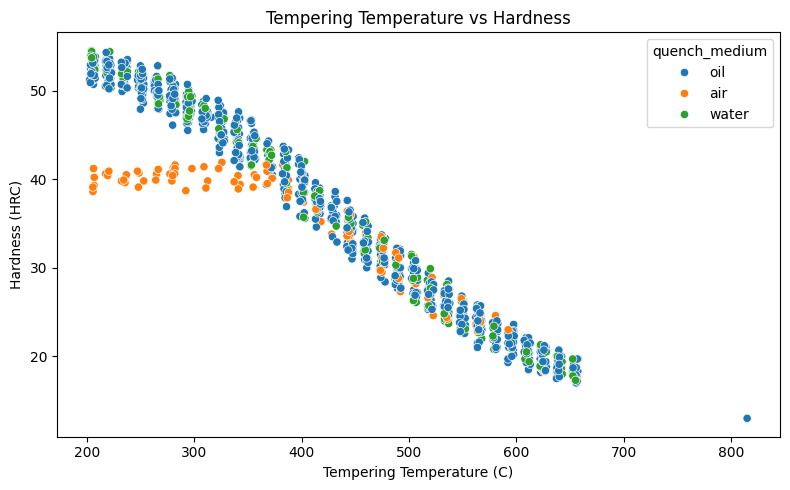

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="tempering_temp_C",
    y="hardness_HRC",
    hue="quench_medium",
)

plt.title("Tempering Temperature vs Hardness")
plt.xlabel("Tempering Temperature (C)")
plt.ylabel("Hardness (HRC)")
plt.tight_layout()
plt.show()

### B. Tempering Temperature vs UTS

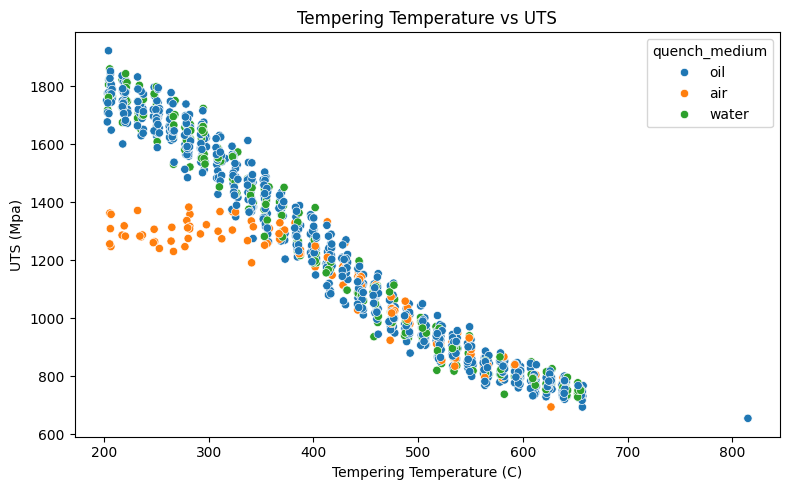

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="tempering_temp_C",
    y="UTS_MPa",
    hue="quench_medium",
)

plt.title("Tempering Temperature vs UTS")
plt.xlabel("Tempering Temperature (C)")
plt.ylabel("UTS (Mpa)")
plt.tight_layout()
plt.show()

### C. Tempering Temperature vs Yield Strength

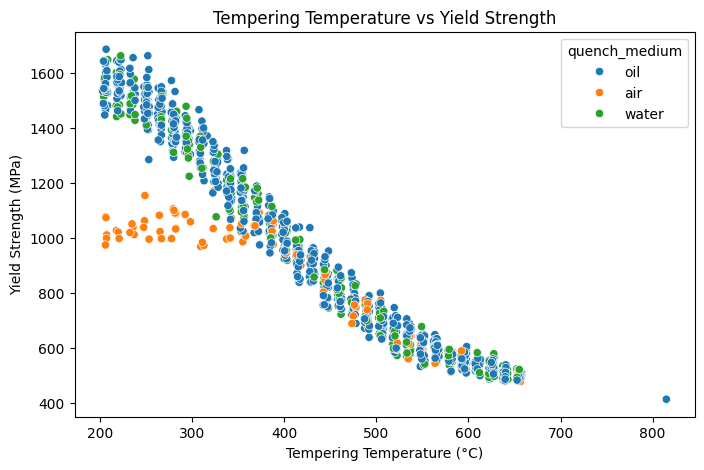

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tempering_temp_C",
    y="YS_MPa",
    hue="quench_medium"
)

plt.title("Tempering Temperature vs Yield Strength")
plt.xlabel("Tempering Temperature (°C)")
plt.ylabel("Yield Strength (MPa)")
plt.show()

### D. Tempering Temperature vs Elongation

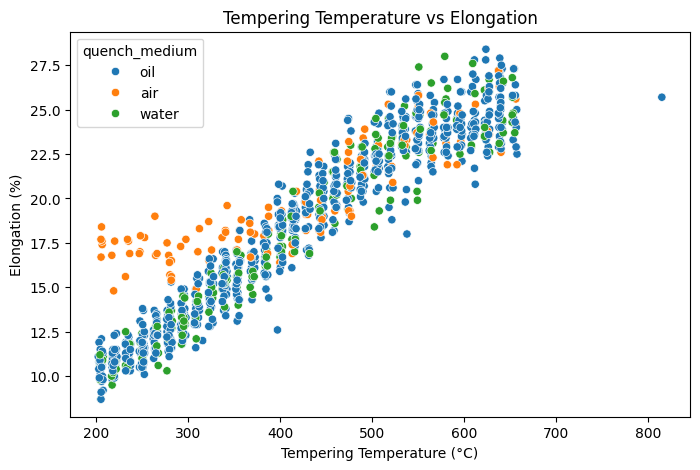

In [14]:
plt.figure(figsize=(8, 5))


sns.scatterplot(
    data=df,
    x="tempering_temp_C",
    y="elongation_pct",
    hue="quench_medium",
)

plt.title("Tempering Temperature vs Elongation")
plt.xlabel("Tempering Temperature (°C)")
plt.ylabel("Elongation (%)")
plt.show()

### E. Tempering Temperature vs Reduction of Area

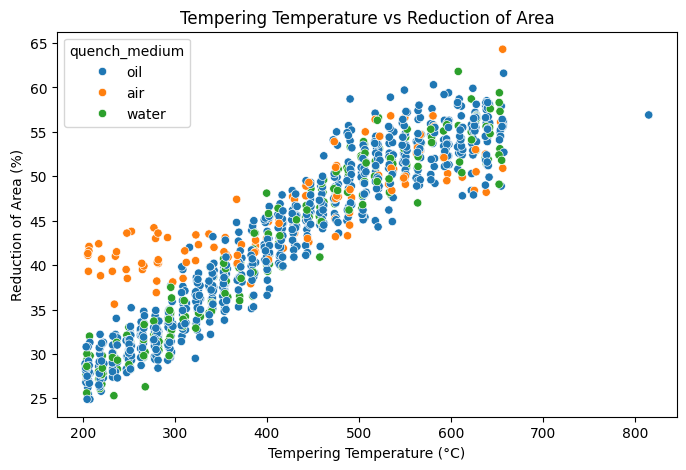

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tempering_temp_C",
    y="reduction_of_area_pct",
    hue="quench_medium",
)

plt.title("Tempering Temperature vs Reduction of Area")
plt.xlabel("Tempering Temperature (°C)")
plt.ylabel("Reduction of Area (%)")
plt.show()

## 11. Strength-Ductility Relationship

Strength and ductility typically trade off against one another. This plot
checks whether that trade-off shows up in this dataset, and whether quench
medium shifts where a given steel sits on that trade-off curve.

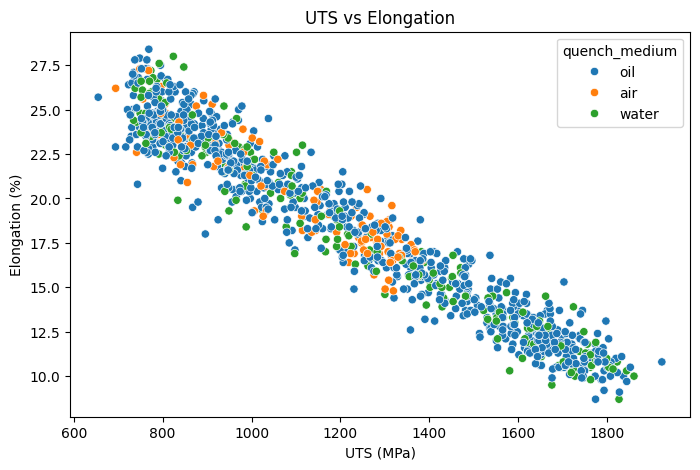

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="UTS_MPa",
    y="elongation_pct",
    hue="quench_medium"
)

plt.title("UTS vs Elongation")
plt.xlabel("UTS (MPa)")
plt.ylabel("Elongation (%)")
plt.show()


## 12. Quench Medium Relation with Mechanical Properties

Having looked at quench medium as a hue in earlier plots, this section isolates
its effect directly: average mechanical properties per quench medium, followed
by boxplots for the two properties where the effect is expected to matter
most.

In [17]:
df.groupby("quench_medium")[[
    "hardness_HRC",
    "UTS_MPa",
    "YS_MPa",
    "elongation_pct",
    "reduction_of_area_pct"
]].mean().round(2)


,hardness_HRC,UTS_MPa,YS_MPa,elongation_pct,reduction_of_area_pct
quench_medium,,,,,
air,33.49,1110.13,851.68,20.01,45.71
oil,36.60,1227.27,988.85,18.31,42.86
water,37.29,1249.14,1004.51,17.95,42.13


### Hardness by Quench Medium

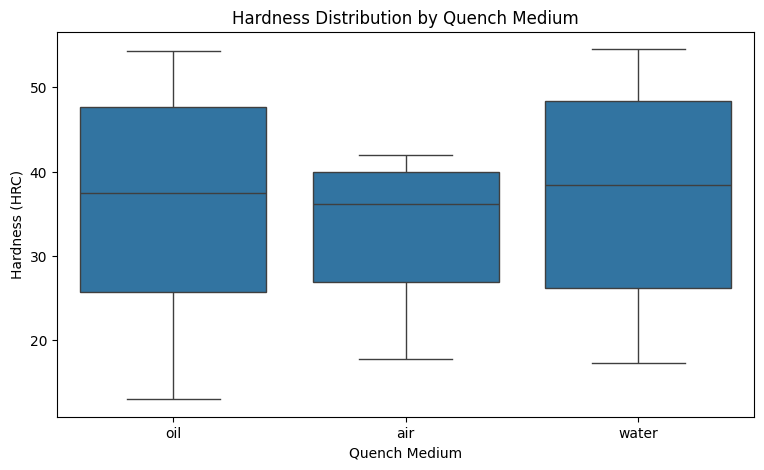

In [18]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="quench_medium",
    y="hardness_HRC"
)

plt.title("Hardness Distribution by Quench Medium")
plt.xlabel("Quench Medium")
plt.ylabel("Hardness (HRC)")
plt.show()

### UTS by Quench Medium

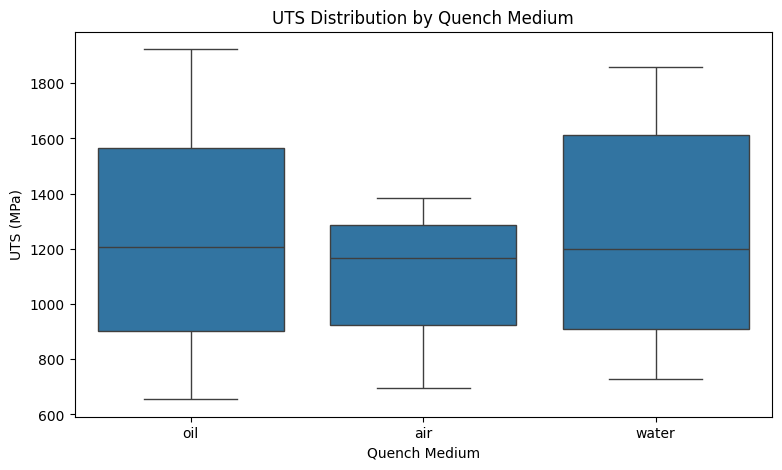

In [19]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="quench_medium",
    y="UTS_MPa"
)

plt.title("UTS Distribution by Quench Medium")
plt.xlabel("Quench Medium")
plt.ylabel("UTS (MPa)")
plt.show()

### YS by Quench Medium

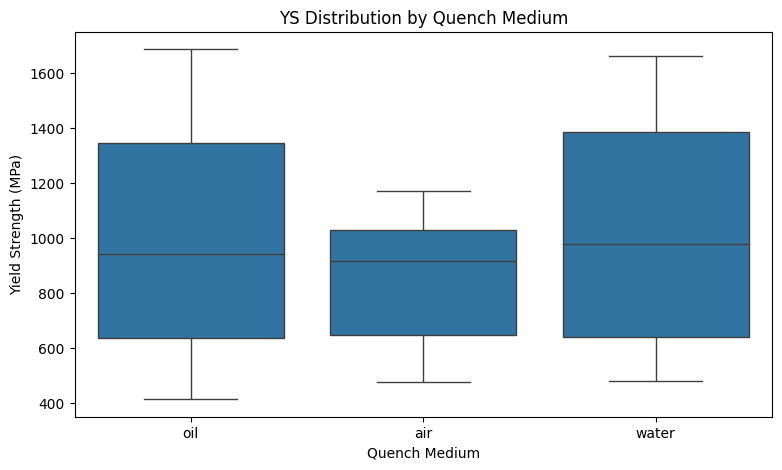

In [20]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="quench_medium",
    y="YS_MPa"
)

plt.title("YS Distribution by Quench Medium")
plt.xlabel("Quench Medium")
plt.ylabel("Yield Strength (MPa)")
plt.show()

### Elongation by Quench Medium

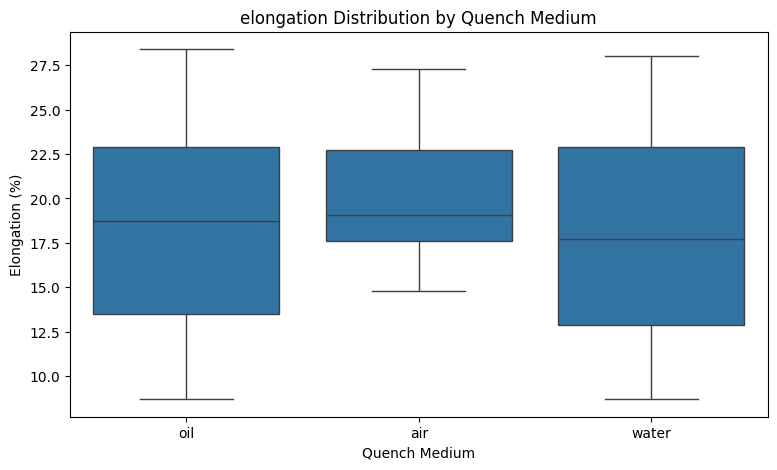

In [21]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="quench_medium",
    y="elongation_pct"
)

plt.title("elongation Distribution by Quench Medium")
plt.xlabel("Quench Medium")
plt.ylabel("Elongation (%)")
plt.show()

### RA by Quench Medium

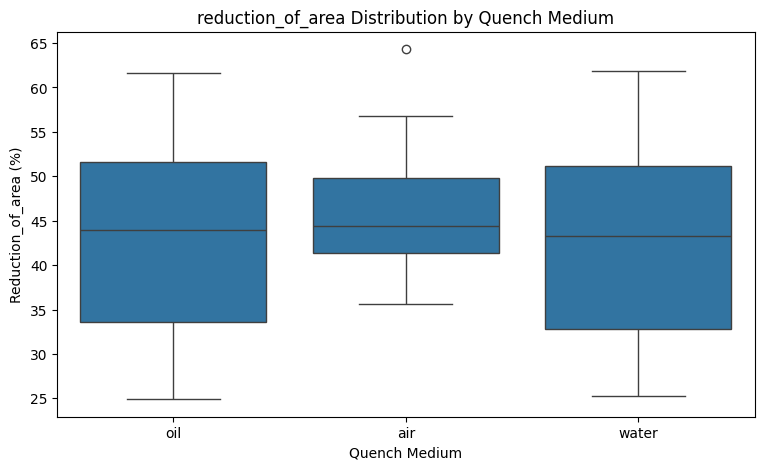

In [22]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="quench_medium",
    y="reduction_of_area_pct"
)

plt.title("reduction_of_area Distribution by Quench Medium")
plt.xlabel("Quench Medium")
plt.ylabel("Reduction_of_area (%)")
plt.show()

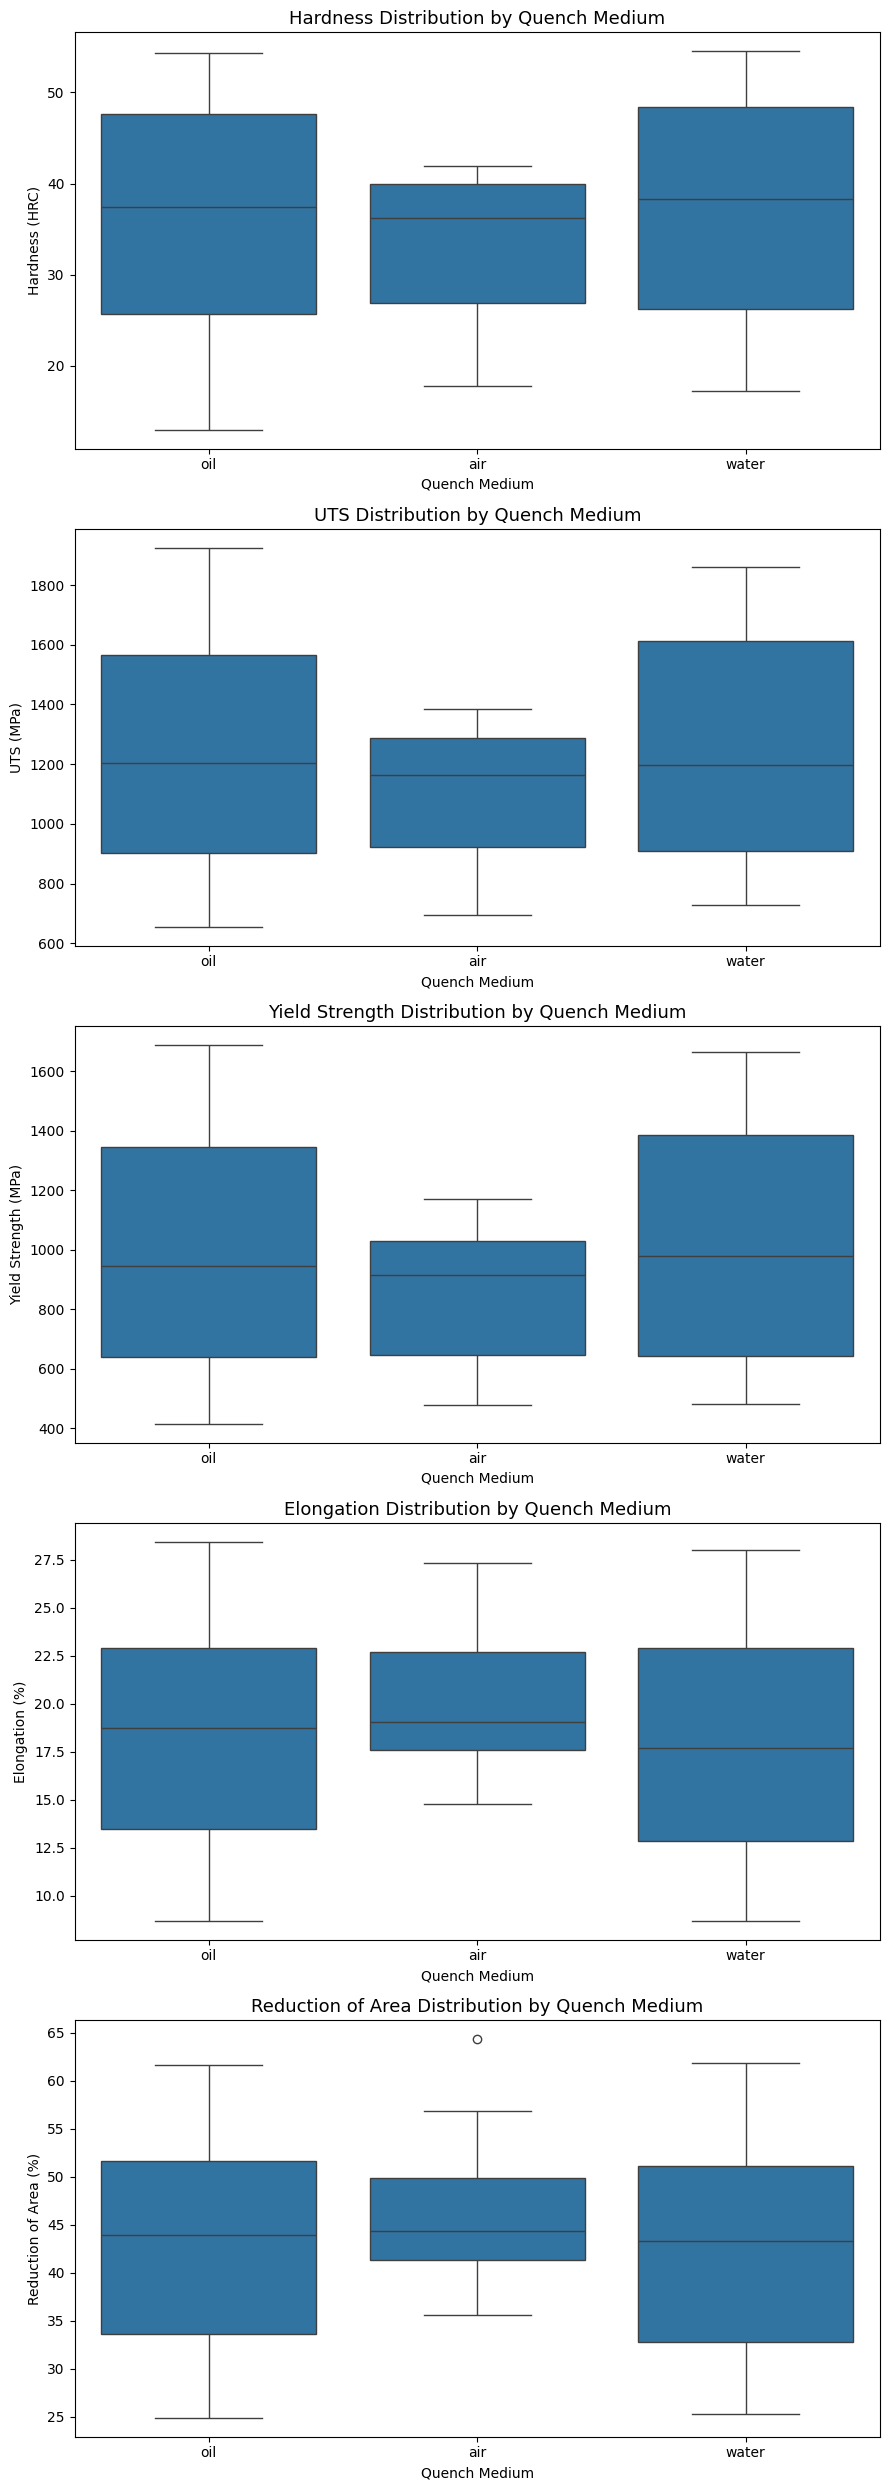

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

properties = [
    "hardness_HRC",
    "UTS_MPa",
    "YS_MPa",
    "elongation_pct",
    "reduction_of_area_pct"
]

titles = [
    "Hardness Distribution by Quench Medium",
    "UTS Distribution by Quench Medium",
    "Yield Strength Distribution by Quench Medium",
    "Elongation Distribution by Quench Medium",
    "Reduction of Area Distribution by Quench Medium"
]

y_labels = [
    "Hardness (HRC)",
    "UTS (MPa)",
    "Yield Strength (MPa)",
    "Elongation (%)",
    "Reduction of Area (%)"
]

fig, axes = plt.subplots(5, 1, figsize=(9, 25))

for ax, prop, title, ylabel in zip(axes, properties, titles, y_labels):

    sns.boxplot(
        data=df,
        x="quench_medium",
        y=prop,
        ax=ax
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Quench Medium")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()